<a href="https://colab.research.google.com/github/nurfnick/NetworkScience/blob/main/HomeworkAssignments/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# CS 5483 Network Science — Project 2


**Important:** You must write all code yourself. This notebook provides **prompts and required outputs** only. Do **not** import third-party libraries beyond the standard scientific stack listed below unless explicitly allowed.



## Environment & Allowed Libraries
- Python 3.x
- `networkx`, `numpy`, `matplotlib`
- (Optional) `community-louvain` for Louvain detection — otherwise implement Girvan–Newman.

> If you use any extra packages, state them in your report **and** justify why they were needed.



## Dataset (choose ONE)
- **Zachary's Karate Club** (built-in to NetworkX)
- **Facebook Social Network** from SNAP (4039 nodes, 88234 edges) — download and load from file
- **Other dataset** (requires instructor approval; include a citation/link in your report)

> Your notebook must clearly show how the data is loaded (file path or built-in loader) and basic graph stats (|V|, |E|, density, components).


## 0. Setup (imports, dataset choice, and basic stats)

In [20]:

# TODO: Import required libraries
# import numpy as np
# import networkx as nx
# import matplotlib.pyplot as plt
# import random

# TODO: Load your chosen dataset into G (an undirected simple graph)
# Example placeholders (REMOVE after implementing your own load path/logic):
# G = nx.karate_club_graph()    # or read edgelist for SNAP

# TODO: Print basic stats: nodes, edges, density, connectedness, component sizes
# print(...)


In [52]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random

G = nx.karate_club_graph()

G.number_of_nodes(), G.number_of_edges(), nx.density(G), nx.is_connected(G), [len(c) for c in sorted(nx.connected_components(G), key=len, reverse=True)]

(34, 78, 0.13903743315508021, True, [34])

I went with the karate club.  I have never seen this example and I like the idea of exploring these built ins as I work through a new language.  It is cheap and I will find tons of examples using this but it gives me a feal for the language at the beginning.  My output above shows that I have one connected component but it has a lot less edges than it could with only 13\% of possible edges existing.


## Part 1 — Centrality Measures (20%)
**Goal:** Compare degree, betweenness, closeness, and eigenvector centrality.

**Required outputs:**
1. Top-5 nodes for each centrality (tabular or printed lists).
2. A short paragraph comparing the rankings: overlaps vs differences and why.
3. One visualization where node size encodes **one** chosen centrality.

**Implementation guidance (write your own code):**
- Compute the four centralities for all nodes.
- If the graph is not connected, handle eigenvector centrality appropriately (e.g., on LCC or by adapting).
- Create a figure and label appropriately.


In [22]:

# TODO: Implement and compute: degree, betweenness, closeness, eigenvector centrality
# TODO: Produce and display the Top-5 lists for each measure
# TODO: Make one visualization (node size ∝ chosen centrality)


In [53]:
print(sorted(nx.degree_centrality(G), key = nx.degree_centrality(G).get, reverse = True)[:5])
print(sorted(nx.betweenness_centrality(G), key = nx.betweenness_centrality(G).get, reverse = True)[:5])
print(sorted(nx.closeness_centrality(G), key = nx.closeness_centrality(G).get, reverse = True)[:5])
print(sorted(nx.eigenvector_centrality(G), key = nx.eigenvector_centrality(G).get, reverse = True)[:5])

[33, 0, 32, 2, 1]
[0, 33, 32, 2, 31]
[0, 2, 33, 31, 8]
[33, 0, 2, 32, 1]


So this was not too bad.  Essentially this gets me all the most connected nodes right away.  We see lots of overlap with 33,0,2 appearing in all four top fives.  Then we see some others appear.  Esspecially in the closeness centrality we get some new unique values.  These might be interesting in bridging the gap between cliques.

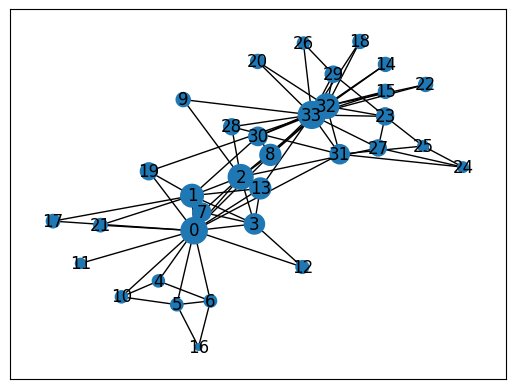

In [54]:
nx.draw_networkx(G, node_size = [v * 1000 for v in nx.eigenvector_centrality(G).values()])

I think I am right about those new important centers in closeness bridging cliques based on this simple vizualization.  Yeah for seeing it in print!  Boo for what the size will actually be in real world problems.


## Part 2 — Cohesion Substructures (20%)
**Goal:** Identify and compare **k-plexes**, **k-components**, and **k-clubs**.

**Required outputs:**
1. Summary of found substructures (counts and size distributions).
2. A list of nodes that appear in multiple substructures (top 10 by frequency).
3. A short discussion of what these overlaps imply about cohesion.

**Implementation guidance (write your own code):**
- **k-components:** use appropriate NetworkX routines or implement logic to identify vertex connectivity-based components by k.
- **k-clubs:** subgraphs whose diameter ≤ k; specify k values you used (e.g., 3 and 4) and your search strategy.
- **k-plexes:** a set on n nodes where each node has degree ≥ n−k within the set; clearly state your enumeration/heuristic strategy and justify scalability choices.


In [25]:

# TODO: Compute/identify k-components and summarize sizes
# TODO: Devise and implement a method to find k-clubs (state k values used)
# TODO: Devise and implement a method to enumerate/approximate k-plexes (state k and approach)
# TODO: Identify nodes appearing across multiple substructures and summarize


In [55]:
kcomp = nx.k_components(G)
print("k-components: Size")
for k in kcomp:
    print(f"k={k}: {len(kcomp[k])}")

k-components: Size
k=4: 1
k=3: 2
k=2: 2
k=1: 1


So these are how many of each of the $k$ levels there are $k$ components.  I want to visualize a subgraph too.

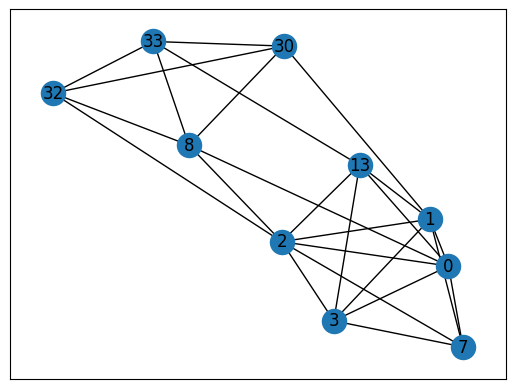

In [27]:
nx.draw_networkx(G.subgraph(kcomp[4][0]) )

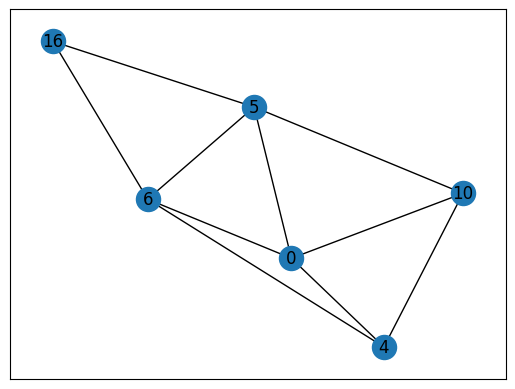

In [28]:
nx.draw_networkx(G.subgraph(kcomp[2][1]) )

I found this last k-component to be the most interesting that these ones were all connected with atleast two edges.  Seems like a tightknit group that falls away from the rest of the main clusters.

To find the $k$-clubs, I am going to create a subgraph and remove the node with the lowest degree from the subgraph until my subgraph has a diameter that is my k value.  I think I'll start with $k=4$ since my diameter is

In [59]:
nx.diameter(G)

5

In [58]:
nG = G.copy()


while(nx.diameter(nG) > 4):
    nG.remove_node(min(nG.degree, key=lambda x: x[1])[0])

print(nx.diameter(nG))

4


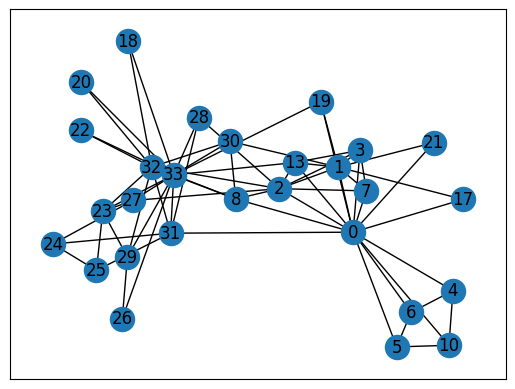

In [31]:
nx.draw_networkx(nG)

This does not look all that different from my original.  I'll look real quick to see the difference in size.

In [60]:
nx.number_of_nodes(nG)

28

So it got rid of 6 components.  This was just a heuristic so we don't know if this is the best 4-club but it is a one!

On to the $k$-plexes.  I spent a bit of time modifying some AI derived code.  This essentially follows a Bron-Kerbosh algorithm.  https://en.wikipedia.org/wiki/Bron%E2%80%93Kerbosch_algorithm This algorithm goes through and builds different subsets of G starting with a single node.  It checks if they make k plex and if they do, adds them to the list.  It also removes single nodes after they have been attempted so you don't use them again.  I had never seen the yield generator used in a function before but it is pretty damn cool too!

In [61]:
import networkx as nx

def find_k_plexes(G, k, min_size=1):
    """
    Generator function to find all maximal k-plexes of at least a minimum size.
    This is a basic, non-optimized implementation.

    Args:
        G (nx.Graph): The input undirected graph.
        k (int): The k-plex parameter.
        min_size (int): The minimum size of the k-plex to be returned.

    Yields:
        set: A set of nodes that form a maximal k-plex.
    """

    def _is_k_plex(subgraph, k_param):
        """Helper to check if a set of nodes forms a k-plex."""
        if not subgraph:
            return False
        n = len(subgraph)
        for node in subgraph:
            degree_in_subgraph = len(list(G.neighbors(node)))

            # Check for neighbors that are not in the subgraph
            external_neighbors = [neighbor for neighbor in G.neighbors(node) if neighbor not in subgraph]
            degree_in_subgraph = degree_in_subgraph - len(external_neighbors)

            # Check if degree in the subgraph is sufficient
            if degree_in_subgraph < (n - k):
                return False
        return True

    def _backtrack(current_plex, candidates, excluded):
        if not candidates and not excluded:
            if len(current_plex) >= min_size and _is_k_plex(current_plex, k):
                yield current_plex
            return

        for node in list(candidates):
            new_plex = current_plex | {node}
            new_candidates = candidates & set(G.neighbors(node))
            new_excluded = excluded & set(G.neighbors(node))

            yield from _backtrack(new_plex, new_candidates, new_excluded)

            candidates.remove(node)
            excluded.add(node)

    # Initial call for each starting node to find all maximal k-plexes
    for node in G.nodes():
        yield from _backtrack({node}, set(G.neighbors(node)), set())


    # A 1-plex is equivalent to a clique
print("Finding 1-plexes (cliques) in the graph:")
for plex in find_k_plexes(G, 1):
    print(plex)

print("\nFinding 2-plexes in the graph:")
for plex in find_k_plexes(G, 2):
    print(plex)


Finding 1-plexes (cliques) in the graph:
{0, 1, 2, 3, 13}
{0, 1, 2, 3, 7}
{0, 1, 17}
{0, 1, 19}
{0, 1, 21}
{0, 8, 2}
{0, 3, 12}
{0, 10, 4}
{0, 4, 6}
{0, 10, 5}
{0, 5, 6}
{0, 11}
{0, 31}
{0, 1, 2, 3, 13}
{0, 1, 2, 3, 7}
{0, 1, 17}
{0, 1, 19}
{0, 1, 21}
{1, 30}
{0, 1, 2, 3, 13}
{0, 1, 2, 3, 7}
{0, 8, 2}
{32, 8, 2}
{9, 2}
{2, 27}
{2, 28}
{0, 1, 2, 3, 13}
{0, 1, 2, 3, 7}
{0, 3, 12}
{0, 10, 4}
{0, 4, 6}
{0, 10, 5}
{0, 5, 6}
{16, 5, 6}
{0, 4, 6}
{0, 5, 6}
{16, 5, 6}
{0, 1, 2, 3, 7}
{8, 0, 2}
{8, 33, 32, 30}
{8, 2, 32}
{9, 33}
{9, 2}
{0, 10, 4}
{0, 10, 5}
{0, 11}
{0, 3, 12}
{0, 1, 2, 3, 13}
{33, 13}
{32, 33, 14}
{32, 33, 15}
{16, 5, 6}
{0, 17, 1}
{32, 33, 18}
{0, 1, 19}
{33, 19}
{32, 33, 20}
{0, 1, 21}
{32, 33, 22}
{32, 33, 29, 23}
{33, 27, 23}
{25, 23}
{24, 25, 31}
{24, 27}
{24, 25, 31}
{25, 23}
{33, 26, 29}
{24, 27}
{33, 27, 23}
{2, 27}
{33, 28, 31}
{2, 28}
{32, 33, 29, 23}
{33, 26, 29}
{8, 33, 32, 30}
{1, 30}
{0, 31}
{32, 33, 31}
{33, 28, 31}
{24, 25, 31}
{32, 33, 8, 30}
{32, 33, 14}
{32, 

A discussion of the cohesion of the group is due.  This is a rather tightly cohesive group.  While we do see some different pieces that are not strongly inside the central group, all are connected and you can make the phone tree smaller only by removing a few people.

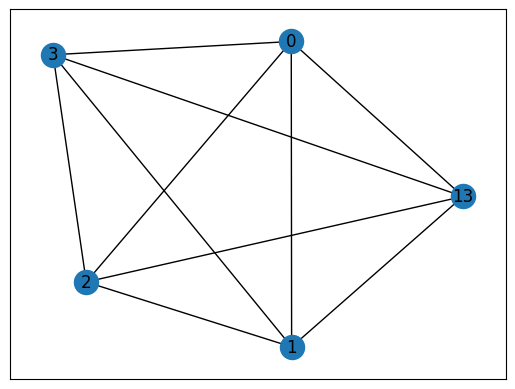

In [62]:
# Take the first 2-plex from the output of the previous cell
first_2_plex = {0, 1, 2, 3, 13}

# Visualize the subgraph of this 2-plex
nx.draw_networkx(G.subgraph(first_2_plex))

Above is a quick visualization of the clique that appeared first (and most often) in my k-plexs.


## Part 3 — Clustering & Structural Balance on Signed Edges (15%)
**Goal:** Compare clustering with a comparable random graph; measure structural balance.

**Required outputs:**
1. Average local clustering and global mean clustering for your graph.
2. For an ER graph with same n and p≈(2m)/(n(n−1)), report average clustering and compare.
3. After assigning **signs** to edges (e.g., −1 to ~20% uniformly at random), compute the **fraction of balanced triads**.
4. A short paragraph comparing observed balance fraction with random-sign expectation.

**Implementation guidance (write your own code):**
- Define how you assign signs (seed, percentage).
- Use the standard balance criterion: product of signs on the three edges in a triangle is +1 → balanced.
- State any sampling strategies if exact enumeration is expensive.


In [35]:

# TODO: Compute clustering coefficients for G
# TODO: Construct an ER graph with matched n and p; compute its clustering
# TODO: Assign signs to edges; compute fraction of balanced triads (exact or sampled); report methodology


In [63]:
nx.clustering(G)

{0: 0.15,
 1: 0.3333333333333333,
 2: 0.24444444444444444,
 3: 0.6666666666666666,
 4: 0.6666666666666666,
 5: 0.5,
 6: 0.5,
 7: 1.0,
 8: 0.5,
 9: 0,
 10: 0.6666666666666666,
 11: 0,
 12: 1.0,
 13: 0.6,
 14: 1.0,
 15: 1.0,
 16: 1.0,
 17: 1.0,
 18: 1.0,
 19: 0.3333333333333333,
 20: 1.0,
 21: 1.0,
 22: 1.0,
 23: 0.4,
 24: 0.3333333333333333,
 25: 0.3333333333333333,
 26: 1.0,
 27: 0.16666666666666666,
 28: 0.3333333333333333,
 29: 0.6666666666666666,
 30: 0.5,
 31: 0.2,
 32: 0.19696969696969696,
 33: 0.11029411764705882}

We see some nodes with high clustering that were not very important in the centrality of the structure.  That is very interesting.  Let's get the average here too.

In [73]:
nx.average_clustering(G)

0.5706384782076823

Next we create a random graph using the same number of nodes and percentage of edges to see how clustered that one would be.  This is a nice simulation to help us compare.

In [74]:
rG = nx.random_graphs.erdos_renyi_graph(n=nx.number_of_nodes(G), p=2*nx.number_of_edges(G)/(nx.number_of_nodes(G)*(nx.number_of_nodes(G)-1)))
nx.average_clustering(rG)


0.14532722179781005

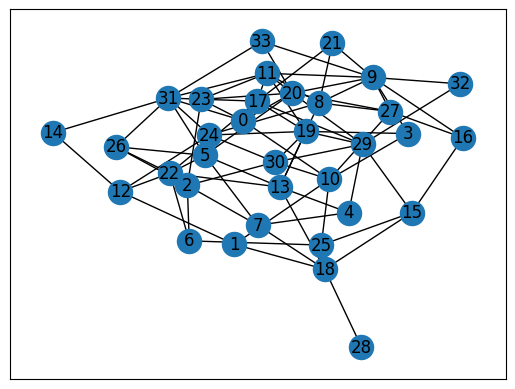

In [70]:
nx.draw_networkx(rG)

We see that our graph is much more clustered than a ER graph with the same statistics.  We can kind of see this in the picture.  We don't notice any strongly centered nodes unlike in the original we saw several central nodes.  Cool!


## Part 4 — Node Similarity Measures (15%)
**Goal:** Compare link-based similarity scores for sampled node pairs.

**Required outputs:**
1. For ~50 random node pairs, compute rankings under **Jaccard**, **Cosine (neighbor-set based)**, and **Adamic-Adar**.
2. Report Top-10 pairs for each metric and discuss consistencies/differences.

**Implementation guidance (write your own code):**
- Implement cosine on neighbor sets: \|Γ(u)∩Γ(v)\| / sqrt(\|Γ(u)\|\|Γ(v)\|).
- Use NetworkX primitives where appropriate, but write the glue code yourself.


In [36]:

# TODO: Sample ~50 node pairs
# TODO: Compute Jaccard, Adamic-Adar, and Cosine similarities
# TODO: Show Top-10 per metric and discuss



## Part 5 — Graph Algorithms: Communities & Shortest Paths (20%)
**Goal:** Detect communities and analyze path lengths.

**Required outputs:**
1. Run **Girvan–Newman** (or Louvain, if available) and report number of communities and their sizes (histogram or summary).
2. Compute **average shortest path length** on the LCC (if graph disconnected).
3. Sample 5 node pairs and report their shortest path lengths vs the average.

**Implementation guidance (write your own code):**
- If using Girvan–Newman, capture the first 1–2 splits and summarize.
- If using Louvain, cite the package and version.
- Be clear about whether you operate on the whole graph or its LCC.


In [37]:

# TODO: Community detection (GN or Louvain) and size summary
# TODO: Average shortest path length on LCC
# TODO: Sample 5 pairs and compute/report shortest paths relative to the average



## Rubric (100%)
- Centrality analysis — 20%
- Cohesion substructures — 20%
- Clustering & structural balance — 20%
- Similarity measures — 20%
- Communities & paths — 20%


**Submission:** Upload this completed notebook (.ipynb) and your PDF report to Canvas.
